# External potentials

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/03-external-potentials.ipynb)

Most of the time the interesting thing is not a system in isolation but a system
*in a galaxy*. tambora treats the galaxy as an external force: a fixed,
analytic potential that acts on the particles without being acted on.

The whole galpy potential library is available for this, which is the practical
reason to use tambora with galpy installed. This notebook covers wrapping a
potential, composing several, running without self-gravity, and the
tidal-tensor shortcut.

**Runtime.** About a minute.

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora/decd93ff-afda-4cd0-b6f6-b9c841213bb2/scratchpad/venv-alpha/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import time

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy.orbit import Orbit
from galpy.potential import (
    HernquistPotential,
    MiyamotoNagaiPotential,
    MWPotential2014,
    NFWPotential,
)

import tambora
from tambora.dynamics import ExternalGalpyPotential
from tambora.simulation import Sim
from tambora.tools import galpy_orbit_to_tambora, mkPlummer_galpy

print("tambora", tambora.__version__)

try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(23)

tambora 0.1.0a1


## 1. The one-line version

`add_external_pot` takes a galpy potential and wraps it for you.

In [3]:
o = Orbit([12.0 * u.kpc, 0.0 * u.km / u.s, 160.0 * u.km / u.s,
           0.0 * u.kpc, 20.0 * u.km / u.s, 0.0 * u.deg])
o.turn_physical_on()

pos, vel, mass = mkPlummer_galpy(
    m=1e7, b=0.06, n=2000,
    center_pos=[o.x(), o.y(), o.z()],
    center_vel=[o.vx(), o.vy(), o.vz()],
)

sim = Sim()
sim.add_particles("cluster", pos, vel, mass)
sim.add_external_pot(MWPotential2014)
sim.run(t_end=0.4, dt=5e-4, dt_out=1e-2, eps=0.01, progress=False)

print(f"|dE/E0| = {sim.monitor.drift['energy'][-1]:.2e}")

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora/decd93ff-afda-4cd0-b6f6-b9c841213bb2/scratchpad/venv-alpha/lib/python3.13/site-packages/tambora/tools/util/_galpy_bridge.py:208: UserWarning: The provided galpy object does not have physical units explicitly set. Using galpy defaults (ro=8.0 kpc, vo=220.0 km/s). Set them explicitly with turn_physical_on(ro=..., vo=...)
  warnings.warn(



|dE/E0| = 7.16e-06


Note that the energy monitor accounts for the external potential — it is part of
the system's energy budget, so a conservative external force still gives you a
meaningful conservation check.

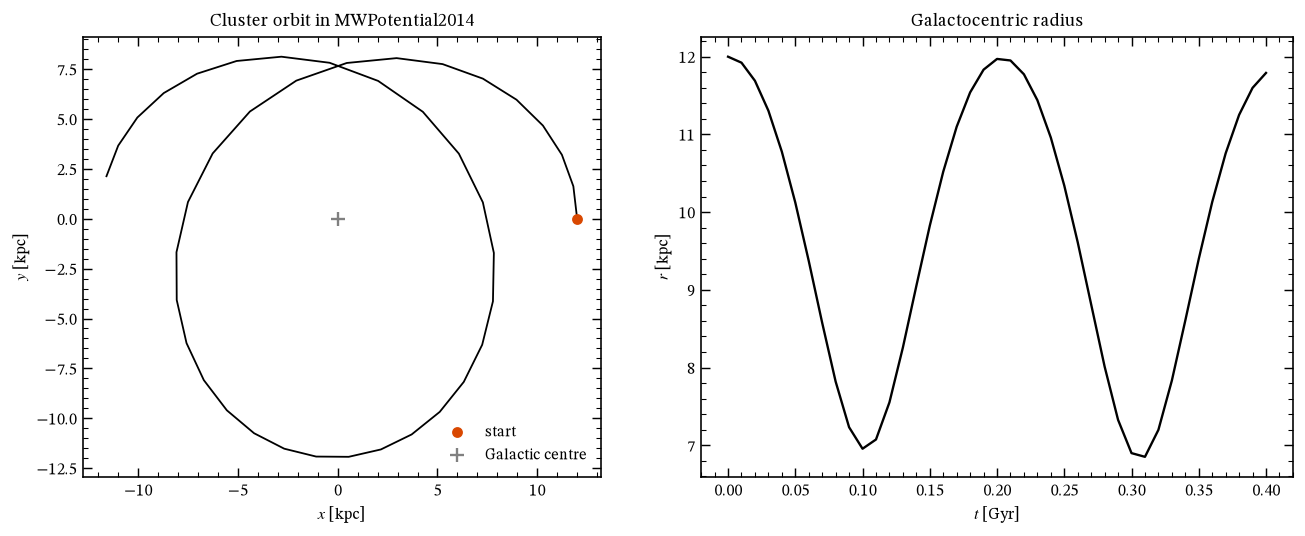

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.4, 4.2))
com = np.array([sim.cluster.pos(t=i).mean(0) for i in range(len(sim.times))])
ax[0].plot(com[:, 0], com[:, 1], c="k", lw=1.0)
ax[0].scatter(*com[0, :2], c="#d94801", s=25, zorder=5, label="start")
ax[0].scatter(0, 0, c="0.5", marker="+", s=60, label="Galactic centre")
ax[0].set_xlabel("$x$ [kpc]")
ax[0].set_ylabel("$y$ [kpc]")
ax[0].set_aspect("equal")
ax[0].legend()
ax[0].set_title("Cluster orbit in MWPotential2014")

ax[1].plot(sim.times, np.linalg.norm(com, axis=1), c="k")
ax[1].set_xlabel("$t$ [Gyr]")
ax[1].set_ylabel("$r$ [kpc]")
ax[1].set_title("Galactocentric radius")
fig.tight_layout()
plt.show()

## 2. Building a galaxy from parts

`MWPotential2014` is itself three components combined. You can assemble your
own the same way.

> **Combine with `+`, not a list.** `add_external_pot` requires a galpy
> `Potential` instance. On galpy >= 1.11, adding potentials with `+` produces a
> `CompositePotential`, which *is* one — and that is why passing
> `MWPotential2014` works. A plain Python list is **not** a `Potential` and
> raises `TypeError: External potential must be a galpy Potential object.`

In [5]:
bulge = HernquistPotential(amp=1.0e10 * u.Msun, a=0.6 * u.kpc, ro=8.0, vo=220.0)
disk = MiyamotoNagaiPotential(amp=6.8e10 * u.Msun, a=3.0 * u.kpc, b=0.28 * u.kpc,
                              ro=8.0, vo=220.0)
halo = NFWPotential(amp=8.0e11 * u.Msun, a=16.0 * u.kpc, ro=8.0, vo=220.0)
for p in (bulge, disk, halo):
    p.turn_physical_on()

# Route A: combine with galpy's `+` into a CompositePotential.
simA = Sim()
simA.add_particles("c", pos, vel, mass)
simA.add_external_pot(bulge + disk + halo)

# Route B: wrap each one and add them with `+`.
force = (
    ExternalGalpyPotential(bulge)
    + ExternalGalpyPotential(disk)
    + ExternalGalpyPotential(halo)
)
simB = Sim()
simB.add_particles("c", pos, vel, mass)
simB.add_external_force(force)

for s, lab in ((simA, "galpy composite"), (simB, "tambora forces")):
    s.run(t_end=0.2, dt=5e-4, dt_out=2e-1, eps=0.01, progress=False)
print("both routes agree:", np.allclose(simA.c.pos(t=-1), simB.c.pos(t=-1)))

# A plain list is rejected -- it is not a Potential:
try:
    Sim().add_external_pot([bulge, disk, halo])
except TypeError as exc:
    print("list form:", exc)

both routes agree: True
list form: External potential must be a galpy Potential object.


Composing with `+` is worth knowing about because it is how you mix a galpy
potential with a force galpy does not provide — a custom drag term, say. The
sum of two conservative forces stays conservative and keeps its `.potential()`;
add a non-conservative one and the result deliberately loses it, so a
half-defined energy raises `AttributeError` instead of returning a wrong number.

## 3. Test particles: turning self-gravity off

If the particles are massless tracers, self-gravity is wasted work. Turning it
off makes the run dramatically faster and is the right choice for orbit
integration, tracer populations, and building intuition.

12 test particles, 1 Gyr: 0.15 s


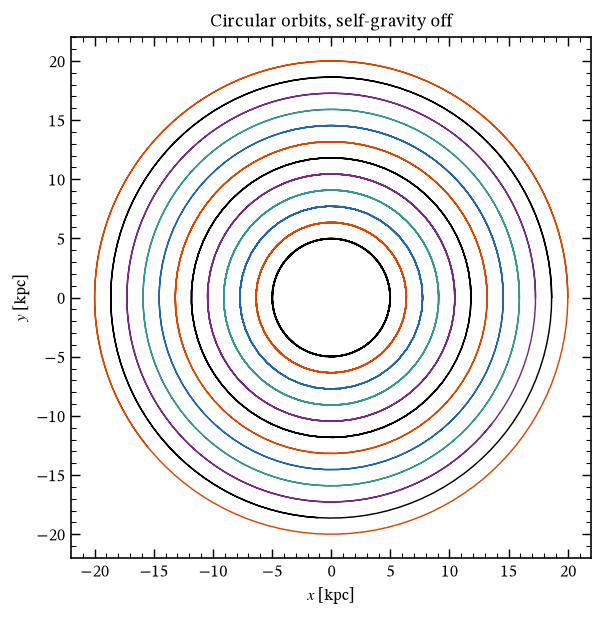

In [6]:
from galpy.potential import evaluateRforces  # noqa: E402

radii = np.linspace(5.0, 20.0, 12)
v_circ = np.sqrt(
    [-evaluateRforces(MWPotential2014, r / 8.0, 0.0, use_physical=False)
     * 220.0**2 / 8.0 * r for r in radii]
)
orbits = Orbit(
    [[r / 8.0, 0.0, vc / 220.0, 0.0, 0.0, 0.0] for r, vc in zip(radii, v_circ)],
    ro=8.0, vo=220.0,
)
orbits.turn_physical_on()
p_t, v_t = galpy_orbit_to_tambora(orbits)
m_t = np.full(len(p_t), 1.0)  # negligible

tp = Sim()
tp.add_particles("tracers", p_t, v_t, m_t)
tp.add_external_pot(MWPotential2014)

t0 = time.time()
# method=None disables self-gravity. `eps` must be dropped with it.
tp.run(t_end=1.0, dt=1e-3, dt_out=5e-3, method=None, progress=False)
print(f"{len(p_t)} test particles, 1 Gyr: {time.time() - t0:.2f} s")

fig, ax = plt.subplots(figsize=(5.4, 5.2))
for k in range(len(p_t)):
    ax.plot(tp.tracers.x()[:, k], tp.tracers.y()[:, k], lw=0.8)
ax.set_xlabel("$x$ [kpc]")
ax.set_ylabel("$y$ [kpc]")
ax.set_aspect("equal")
ax.set_title("Circular orbits, self-gravity off")
plt.show()

:::{note}
`method=None` selects `NullSelfGravity`, which returns zeros. Softening is a
self-gravity parameter, so passing `eps` alongside it is rejected:

```text
ValueError: {'eps'} is (are) invalid kwarg(s) for None self-gravity method.
```

There is no `turn_self_gravity_off()` in the released alpha.
:::

## 4. Which potentials are supported?

tambora's galpy bridge vectorises the potential evaluation where galpy allows
it, and falls back to a per-particle loop where it does not. Both work; the
vectorised path is much faster.

In [7]:
from tambora.tools.util._galpy_bridge import (  # noqa: E402
    UNVECTORIZED_POTENTIALS,
    VECTORIZED_POTENTIALS,
)

print(f"{len(VECTORIZED_POTENTIALS)} vectorised, "
      f"{len(UNVECTORIZED_POTENTIALS)} looped\n")
print("vectorised (fast):")
print("  " + ", ".join(sorted(p.__name__ for p in VECTORIZED_POTENTIALS)[:12]) + ", ...")
print("\nlooped (slower):")
print("  " + ", ".join(sorted(p.__name__ for p in UNVECTORIZED_POTENTIALS)))

33 vectorised, 8 looped

vectorised (fast):
  BurkertPotential, DehnenBarPotential, DehnenCoreSphericalPotential, DehnenSphericalPotential, EinastoPotential, FlattenedPowerPotential, HernquistPotential, IsochronePotential, JaffePotential, KeplerPotential, KingPotential, KuzminDiskPotential, ...

looped (slower):
  DoubleExponentialDiskPotential, FerrersPotential, HomogeneousSpherePotential, MovingObjectPotential, NullPotential, RazorThinExponentialDiskPotential, SoftenedNeedleBarPotential, SphericalShellPotential


Passing an unsupported potential raises immediately at
`add_external_pot`/`add_external_force` time, rather than failing partway
through a long run.

## 5. Time-dependent potentials

galpy's wrapper potentials — growing bars, rotating patterns, amplitude ramps —
are supported and the time dependence is passed through, because tambora calls
the potential with the current simulation time at every step.

In [8]:
from galpy.potential import DehnenBarPotential, DehnenSmoothWrapperPotential  # noqa: E402

bar = DehnenBarPotential(omegab=1.3, rb=0.5, Af=0.01)
grown = DehnenSmoothWrapperPotential(pot=bar, tform=-4.0, tsteady=2.0)

sim_bar = Sim()
sim_bar.add_particles("tracers", p_t, v_t, m_t)
sim_bar.add_external_pot(MWPotential2014 + grown)
sim_bar.run(t_end=0.5, dt=1e-3, dt_out=1e-2, method=None, progress=False)
print(f"ran with a growing bar; |dE/E0| = {sim_bar.monitor.drift['energy'][-1]:.2e}")

ran with a growing bar; |dE/E0| = 6.87e-03


The energy drift is larger here, and that is physics rather than error: a
time-dependent potential does work on the system, so total energy is genuinely
not conserved. The monitor is still useful — but interpret it as "how much
energy the bar injected", not "how wrong the integrator is".

## 6. The tidal-tensor shortcut

For a bound satellite you often want only the *tidal* part of the external
field, with the bulk acceleration removed.
{class}`~tambora.dynamics.TidalTensorGalpyForce` linearises the host potential
about a chosen centre and applies only the strain.

In [9]:
from tambora.dynamics import TidalTensorGalpyForce  # noqa: E402

centre = np.array([12.0, 0.0, 0.0])
tt = TidalTensorGalpyForce(MWPotential2014, center=centre)
T = tt.tidal_tensor(np.array([centre]))
eig = np.linalg.eigvalsh(T)
print("tidal tensor eigenvalues [1/Gyr^2]:", np.round(eig, 1))
print("one stretching (+), two compressing (-)")

tidal tensor eigenvalues [1/Gyr^2]: [-2027.3  -320.1   398.1]
one stretching (+), two compressing (-)


The [tidal stripping notebook](05-tidal-stripping.ipynb) works through what this
is good for and where it stops being valid.

## Summary

| Task | Call |
| --- | --- |
| Add a galpy potential | `sim.add_external_pot(pot)` |
| Add several | `sim.add_external_pot(p1 + p2 + p3)` |
| Compose explicitly | `sim.add_external_force(F1 + F2)` |
| Tides only | `sim.add_external_force(TidalTensorGalpyForce(pot, center=...))` |
| Test particles | `sim.run(..., method=None)`, and drop `eps` |

## Next

- [04 · Tidal streams](04-tidal-stream.ipynb) — self-gravity and an external
  potential together, which is where it gets interesting.
- [External forces](../guide/external-forces.md) — the reference version,
  including writing your own force class.